In [21]:
df = pd.read_csv('../data/collisions_clean.csv', parse_dates=['CRASH DATE'])

print(f'Dataset: {len(df):,} records, {df.shape[1]} columns')
print(f'Date range: {df["CRASH DATE"].min().date()} to {df["CRASH DATE"].max().date()}')
df.head(3)

Dataset: 375,025 records, 29 columns
Date range: 2022-02-03 to 2026-01-30


,CRASH DATE,year,month,day_of_week,hour,is_weekend,season,BOROUGH,ZIP CODE,LATITUDE,...,total_casualties,severity,has_injury,has_fatality,has_pedestrian_casualty,has_cyclist_casualty,primary_factor,factor_category,vehicle_type_clean,num_vehicles
0,2022-02-03,2022,2,3,16,0,Winter,QUEENS,11360.0,40.737682,...,0,Property Damage Only,0,0,0,0,NaN,Unknown,Unknown,0
1,2022-02-03,2022,2,3,18,0,Winter,MANHATTAN,10036.0,40.853214,...,1,Injury,1,0,0,1,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Pedestrian/Cyclist Error,Sedan,2
2,2022-02-03,2022,2,3,22,0,Winter,QUEENS,11385.0,40.585934,...,0,Property Damage Only,0,0,0,0,NaN,Unknown,Pickup Truck,1


In [22]:
# --- Temporal features ---
df['year'] = df['CRASH DATE'].dt.year
df['month'] = df['CRASH DATE'].dt.month
df['day_of_week'] = df['CRASH DATE'].dt.dayofweek
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'

df['season'] = df['month'].apply(get_season)

def time_interval(hour):
    if pd.isna(hour): return 'Unknown'
    hour = int(hour)
    if 6 <= hour <= 9: return 'Morning Rush'
    elif 10 <= hour <= 15: return 'Midday'
    elif 16 <= hour <= 19: return 'Evening Rush'
    elif 20 <= hour <= 23: return 'Night'
    else: return 'Late Night'

df['time_interval'] = df['hour'].apply(time_interval)

# --- Target variable ---
df['target_severity'] = df['severity'].apply(lambda x: 1 if x in ['Injury', 'Fatal'] else 0)

# --- Encode categoricals ---
df['BOROUGH'] = df['BOROUGH'].fillna('Unknown')
df['vehicle_type_clean'] = df['vehicle_type_clean'].fillna('Unknown')
df['factor_category'] = df['factor_category'].fillna('Unknown')

# One-hot encoding
cat_cols = ['BOROUGH', 'vehicle_type_clean', 'factor_category', 'season', 'time_interval']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('Features prepared.')
print(f'Total columns after encoding: {df_encoded.shape[1]}')

Features prepared.
Total columns after encoding: 66


In [23]:
temporal_cutoff = pd.to_datetime('2024-01-01')

train_df = df_encoded[df_encoded['CRASH DATE'] < temporal_cutoff].copy()
test_df = df_encoded[df_encoded['CRASH DATE'] >= temporal_cutoff].copy()

# Define feature columns — exclude targets, IDs, raw text, dates, outcome columns
exclude_cols = [
    'COLLISION_ID', 'CRASH DATE', 'ON STREET NAME', 'CROSS STREET NAME',
    'severity', 'target_severity',
    'total_injured', 'total_killed', 'total_casualties',
    'has_injury', 'has_fatality', 'has_pedestrian_casualty', 'has_cyclist_casualty',
    'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
    'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
    'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
    'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
    'LATITUDE', 'LONGITUDE', 'ZIP CODE',
    'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
    'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
    'primary_factor', 'time_period',
]

feature_cols = [c for c in df_encoded.columns if c not in exclude_cols and df_encoded[c].dtype in ['int64', 'float64', 'uint8', 'bool']]

X_train = train_df[feature_cols].fillna(0)
X_test = test_df[feature_cols].fillna(0)
y_train = train_df['target_severity']
y_test = test_df['target_severity']

print(f'Train: {X_train.shape[0]:,} records, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} records, {X_test.shape[1]} features')
print(f'\nTrain target rate: {y_train.mean()*100:.1f}% Injury/Fatal')
print(f'Test target rate:  {y_test.mean()*100:.1f}% Injury/Fatal')

Train: 192,037 records, 43 features
Test:  182,988 records, 43 features

Train target rate: 40.2% Injury/Fatal
Test target rate:  43.8% Injury/Fatal


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_results = {
    "Accuracy": accuracy_score(y_test, rf_preds),
    "Precision": precision_score(y_test, rf_preds),
    "Recall": recall_score(y_test, rf_preds),
    "F1": f1_score(y_test, rf_preds),
    "ROC_AUC": roc_auc_score(y_test, rf_probs)
}

# Print results
for metric, value in rf_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.6215
Precision: 0.5929
Recall: 0.4316
F1: 0.4996
ROC_AUC: 0.6443


In [27]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(15))

hour                                         0.270341
num_vehicles                                 0.110737
is_weekend                                   0.052240
factor_category_Failure to Yield             0.041331
season_Spring                                0.035374
season_Summer                                0.034932
season_Winter                                0.032624
vehicle_type_clean_E-Bike/E-Scooter          0.025355
BOROUGH_BROOKLYN                             0.024466
vehicle_type_clean_SUV/Station Wagon         0.023707
BOROUGH_QUEENS                               0.022018
vehicle_type_clean_Sedan                     0.021195
BOROUGH_Unknown                              0.020708
BOROUGH_MANHATTAN                            0.019407
factor_category_Improper Lane Use/Passing    0.017476
dtype: float64


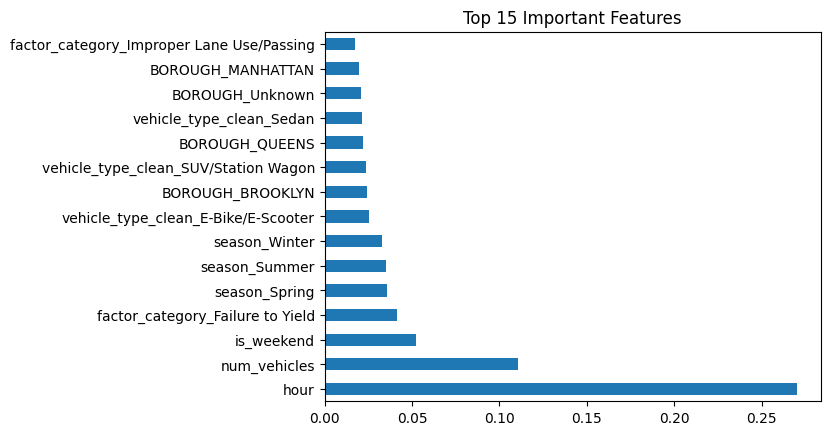

In [28]:
import matplotlib.pyplot as plt

importance.head(15).plot(kind='barh')
plt.title("Top 15 Important Features")
plt.show()

In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

xgb_results = {
    "Accuracy": accuracy_score(y_test, xgb_preds),
    "Precision": precision_score(y_test, xgb_preds),
    "Recall": recall_score(y_test, xgb_preds),
    "F1": f1_score(y_test, xgb_preds),
    "ROC_AUC": roc_auc_score(y_test, xgb_probs)
}

print("\nXGBoost Results:")
for k, v in xgb_results.items():
    print(f"{k}: {v:.4f}")

/Users/sannain/tf_apple_env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:53:19] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
Accuracy: 0.6569
Precision: 0.7340
Recall: 0.3390
F1: 0.4637
ROC_AUC: 0.7005


In [30]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_preds = lgbm.predict(X_test)
lgbm_probs = lgbm.predict_proba(X_test)[:, 1]

lgbm_results = {
    "Accuracy": accuracy_score(y_test, lgbm_preds),
    "Precision": precision_score(y_test, lgbm_preds),
    "Recall": recall_score(y_test, lgbm_preds),
    "F1": f1_score(y_test, lgbm_preds),
    "ROC_AUC": roc_auc_score(y_test, lgbm_probs)
}

print("\nLightGBM Results:")
for k, v in lgbm_results.items():
    print(f"{k}: {v:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 77188, number of negative: 114849
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001949 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 112
[LightGBM] [Info] Number of data points in the train set: 192037, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.401943 -> initscore=-0.397374
[LightGBM] [Info] Start training from score -0.397374

LightGBM Results:
Accuracy: 0.6583
Precision: 0.7336
Recall: 0.3445
F1: 0.4688
ROC_AUC: 0.7047


In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

best_rf = grid.best_estimator_

best_preds = best_rf.predict(X_test)
best_probs = best_rf.predict_proba(X_test)[:, 1]

tuned_results = {
    "Accuracy": accuracy_score(y_test, best_preds),
    "Precision": precision_score(y_test, best_preds),
    "Recall": recall_score(y_test, best_preds),
    "F1": f1_score(y_test, best_preds),
    "ROC_AUC": roc_auc_score(y_test, best_probs)
}

print("\nTuned Random Forest Results:")
for k, v in tuned_results.items():
    print(f"{k}: {v:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

Tuned Random Forest Results:
Accuracy: 0.6305
Precision: 0.6113
Recall: 0.4278
F1: 0.5034
ROC_AUC: 0.6587


In [32]:
import pandas as pd

comparison = pd.DataFrame({
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
    "LightGBM": lgbm_results,
    "Tuned RF": tuned_results
}).T

print("\nModel Comparison:")
print(comparison.sort_values("F1", ascending=False))


Model Comparison:
               Accuracy  Precision    Recall        F1   ROC_AUC
Tuned RF       0.630539   0.611333  0.427835  0.503383  0.658710
Random Forest  0.621538   0.592909  0.431606  0.499559  0.644282
LightGBM       0.658338   0.733573  0.344450  0.468783  0.704721
XGBoost        0.656917   0.733973  0.338956  0.463749  0.700539
